In [1]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
fm_test = FashionMNIST(root='.', train=False, download=True)

train_input = fm_train.data
train_target = fm_train.targets
train_scaled = train_input.reshape(-1, 1, 28, 28) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
            train_scaled, train_target, test_size=0.2, random_state=42)


In [2]:
from torchinfo import summary 

In [3]:
import torch.nn as nn
import torch

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten())

model.add_module('dense1', nn.Linear(3136, 100))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100, 10))


In [4]:
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─ReLU: 1-5                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 64, 7, 7]             --
├─Flatten: 1-7                           [1, 3136]                 --
├─Linear: 1-8                            [1, 100]                  313,700
├─ReLU: 1-9                              [1, 100]                  --
├─Dropout: 1-10                          [1, 100]                  --
├─Linear: 1-11                           [1, 10]                   1,010
Total params: 333,526
Trainable params: 333,526
Non-trainable params: 0


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [6]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [7]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
for epoch in range(epochs):
      model.train()

train_loss = 0
for inputs, targets in train_loader:
     inputs, targets = inputs.to(device), targets.to(device)
     optimizer.zero_grad()
     outputs = model(inputs)
     loss = criterion(outputs, targets)
     loss.backward()
     optimizer.step()
     train_loss += loss.item()

In [8]:
for epoch in range(epochs):

    # 1. 훈련
    model.train()
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # 2. 검증
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    # 3. 에포크 끝난 뒤 평균 계산
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    # 4. 기록 저장
    train_hist.append(train_loss)
    val_hist.append(val_loss)

    # 5. 출력
    print(f"에포크:{epoch+1}, 훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    # 6. 최고 성능 저장 + early stopping
    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_cnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.3537, 검증 손실:0.3004
에포크:2, 훈련 손실:0.3032, 검증 손실:0.2665
에포크:3, 훈련 손실:0.2726, 검증 손실:0.2577
에포크:4, 훈련 손실:0.2469, 검증 손실:0.2551
에포크:5, 훈련 손실:0.2265, 검증 손실:0.2348
에포크:6, 훈련 손실:0.2102, 검증 손실:0.2503
에포크:7, 훈련 손실:0.1951, 검증 손실:0.2282
에포크:8, 훈련 손실:0.1823, 검증 손실:0.2325
에포크:9, 훈련 손실:0.1677, 검증 손실:0.2253
에포크:10, 훈련 손실:0.1579, 검증 손실:0.2349
에포크:11, 훈련 손실:0.1483, 검증 손실:0.2319
11번째 에포크에서 조기 종료되었습니다.


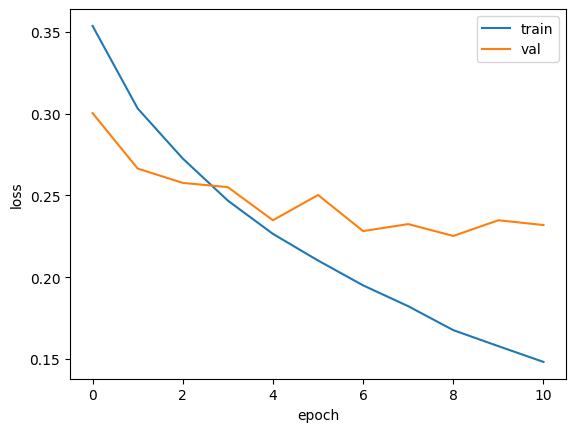

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [10]:
model.load_state_dict(torch.load('best_cnn_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          predicts = torch.argmax(outputs, 1)
          corrects += (predicts == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9181


In [11]:
test_scaled = fm_test.data.reshape(-1, 1, 28, 28) / 255.0
test_target = fm_test.targets
test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
         inputs, targets = inputs.to(device), targets.to(device)
         outputs = model(inputs)
         predicts = torch.argmax(outputs, 1)
         corrects += (predicts == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"테스트 정확도: {accuracy:.4f}")


테스트 정확도: 0.9104
